# 89% vs 34%. ¿Está la IA superando a los médicos?

**Paper:** Brodeur et al. (2026). *Performance of a large language model on the reasoning tasks of a physician*. Science.
**DOI:** [10.1126/science.adz4433](https://doi.org/10.1126/science.adz4433)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-30-llm-razonamiento-medico/notebook.ipynb)

**Video:** [Pendiente]

## El experimento

El equipo de Brodeur puso a un modelo de OpenAI (o1-preview, sucesor de GPT-4) a competir con médicos en **seis tareas de razonamiento clínico**: desde diagnósticos de los casos clinico-patológicos del *New England Journal of Medicine* hasta decisiones en urgencias reales.

El titular es que la IA ganó casi todas. La pregunta interesante: ¿qué tan ancha es la ventaja, y dónde se cierra?

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_LLM = '#2563EB'        # azul — la IA
COLOR_HUMANO = '#999999'     # gris — médicos
COLOR_GAP = '#DC2626'        # rojo — diferencia destacada
COLOR_NS = '#D97706'         # amber — no significativo
FUENTE = 'Fuente: Brodeur et al. (2026), Science 10.1126/science.adz4433 | Datos: Tablas S1, S2, S6, S7'

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Cargar estilo CaM (local → fallback GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# Cargar los CSVs derivados de las tablas Supplementary
exp = pd.read_csv('datos/experimentos_headlines.csv')
cpc = pd.read_csv('datos/cpc_accuracy.csv')
er = pd.read_csv('datos/er_touchpoints.csv')
prob = pd.read_csv('datos/prob_reasoning_pretest.csv')
cutoff = pd.read_csv('datos/cutoff_sensitivity.csv')
blind = pd.read_csv('datos/blinding_raters.csv')

n_overlap = cpc[cpc['entidad']=='o1_preview']['n_casos'].values[0]
print('Experimentos cargados:', len(exp))
print('CPCs NEJM (n casos solapados):', n_overlap)
print('ER touchpoints (n pacientes): 76')
print('Tests de blinding (raters):', len(blind))

Experimentos cargados: 6
CPCs NEJM (n casos solapados): 101
ER touchpoints (n pacientes): 76
Tests de blinding (raters): 2


## Los seis frentes

Aquí están.

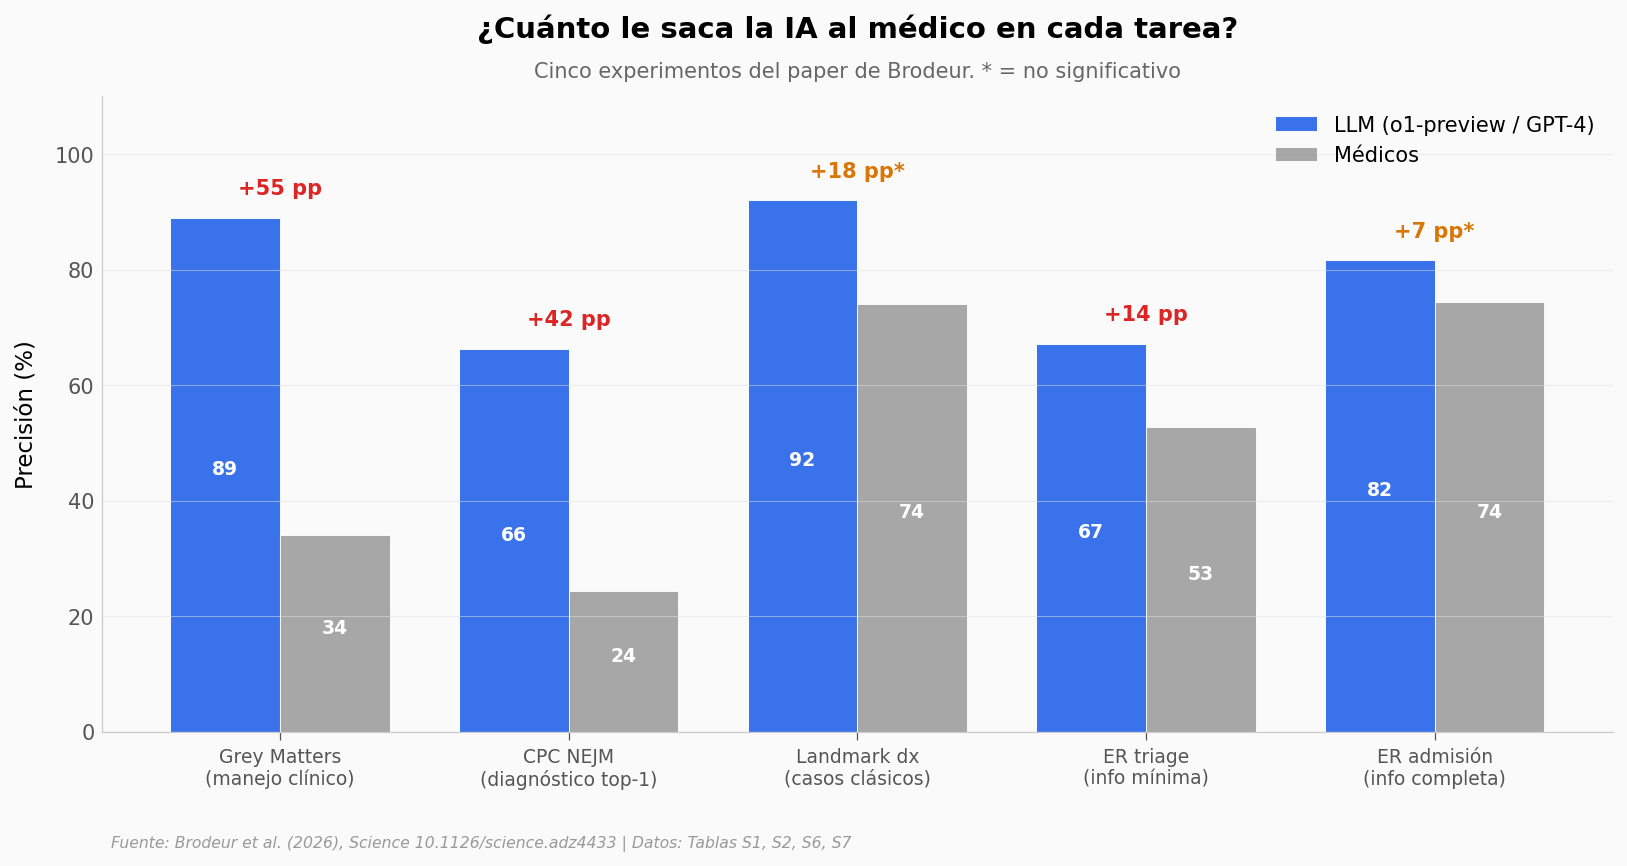

In [2]:
# Gráfica hero: experimentos lado a lado — IA vs humano
# Cannot-miss queda sin barras (el paper reporta diferencia no significativa sin pp explícito)
df = exp.dropna(subset=['llm_pct', 'humano_pct']).copy()
df = df.sort_values('gap_pp', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 5.5))
x = np.arange(len(df))
width = 0.38

bars_llm = ax.bar(x - width/2, df['llm_pct'], width, color=COLOR_LLM, alpha=0.9,
                  edgecolor='white', linewidth=0.5, label='LLM (o1-preview / GPT-4)')
bars_hum = ax.bar(x + width/2, df['humano_pct'], width, color=COLOR_HUMANO, alpha=0.85,
                  edgecolor='white', linewidth=0.5, label='Médicos')

# Etiquetas de gap encima de cada par
for i, row in df.iterrows():
    y_top = max(row['llm_pct'], row['humano_pct'])
    color = COLOR_GAP if row['sig'] == 'si' else COLOR_NS
    label = f"+{row['gap_pp']:.0f} pp"
    if row['sig'] != 'si':
        label += '*'
    ax.text(i, y_top + 4, label, ha='center', fontsize=10,
            fontweight='bold', color=color)

# Valores dentro de las barras
for bar, val in zip(bars_llm, df['llm_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, val/2, f'{val:.0f}',
            ha='center', fontsize=9, color='white', fontweight='bold')
for bar, val in zip(bars_hum, df['humano_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, val/2, f'{val:.0f}',
            ha='center', fontsize=9, color='white', fontweight='bold')

labels = ['Grey Matters' + chr(10) + '(manejo clínico)',
          'CPC NEJM' + chr(10) + '(diagnóstico top-1)',
          'Landmark dx' + chr(10) + '(casos clásicos)',
          'ER triage' + chr(10) + '(info mínima)',
          'ER admisión' + chr(10) + '(info completa)']
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Precisión (%)', fontsize=11)
ax.set_ylim(0, 110)
ax.set_title('¿Cuánto le saca la IA al médico en cada tarea?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cinco experimentos del paper de Brodeur. * = no significativo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_seis_experimentos.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que llama la atención

El gap más grande viene del experimento más blando: *Grey Matters* (casos de manejo clínico) usa una rúbrica tipo checklist — sumas puntos por cada acción correcta, sin penalización por enumerar de más. La IA enumera generosamente. Eso explica buena parte de los **55 puntos** de diferencia.

A medida que las tareas se aprietan, el gap se encoge. En **CPC NEJM** la IA todavía dobla la precisión humana (66.3% vs 24.3% en los 101 casos solapados), pero ya con una rúbrica que mide "¿está el diagnóstico correcto en tu top-1?". En **Landmark cases** — casos diagnósticos clásicos — el gap cae a 18 puntos y la diferencia *con médicos asistidos por GPT-4* deja de ser significativa (p=0.055).

Y los diagnósticos críticos que no se pueden dejar pasar (*cannot-miss*) ni siquiera tienen barras: el paper enmarca esa comparación como diferencia no significativa.

## La prueba más limpia: urgencias reales

Aquí el equipo hizo algo distinto. Cogieron **76 pacientes reales de una sala de urgencias** y pidieron tanto a o1-preview como a dos médicos de planta (con todo su entrenamiento) que diagnosticaran al mismo paciente en dos momentos:

1. **Triage** — apenas con la queja inicial. Información mínima.
2. **Admisión** — después de exploración, labs e imágenes. Información completa.

Misma persona, mismos médicos, mismo modelo. Solo cambia cuánto sabe cada uno.

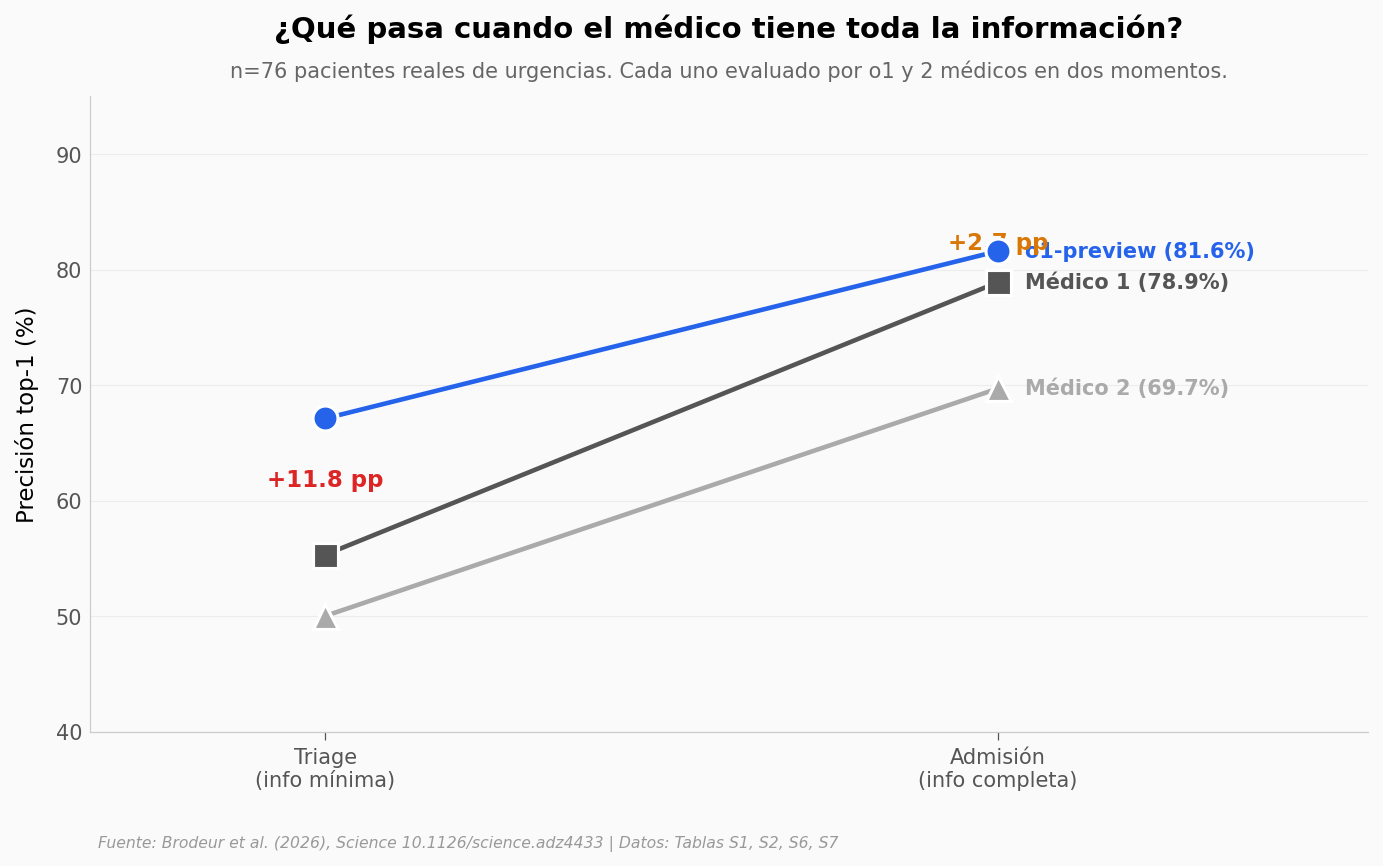

Cierre del gap (vs Médico 1): 11.8 pp -> 2.7 pp
Reducción: 9.1 puntos porcentuales


In [3]:
# Gap shrinking: triage → admisión
fig, ax = plt.subplots(figsize=(11, 5.5))

touchpoints = ['triage', 'admision']
x_pos = [0, 1]
labels_x = ['Triage' + chr(10) + '(info mínima)',
            'Admisión' + chr(10) + '(info completa)']

entities = [
    ('o1', 'o1-preview', COLOR_LLM, 'o'),
    ('medico_1', 'Médico 1', '#555555', 's'),
    ('medico_2', 'Médico 2', '#AAAAAA', '^'),
]

for ent_key, ent_label, color, marker in entities:
    vals = [er[(er['touchpoint']==tp) & (er['entidad']==ent_key)]['top1_pct'].values[0]
            for tp in touchpoints]
    ax.plot(x_pos, vals, color=color, linewidth=2.2, marker=marker,
            markersize=12, markeredgecolor='white', markeredgewidth=1.5,
            label=ent_label, zorder=5)
    ax.text(1.04, vals[1], f'{ent_label} ({vals[1]:.1f}%)',
            fontsize=10, color=color, fontweight='bold', va='center')

gap_triage = 67.1 - 55.3
gap_admision = 81.6 - 78.9
ax.annotate(f'+{gap_triage:.1f} pp', xy=(0, (67.1+55.3)/2),
            fontsize=11, color=COLOR_GAP, fontweight='bold', ha='center')
ax.annotate(f'+{gap_admision:.1f} pp', xy=(1, (81.6+78.9)/2 + 1.5),
            fontsize=11, color=COLOR_NS, fontweight='bold', ha='center')

ax.set_xticks(x_pos)
ax.set_xticklabels(labels_x, fontsize=10)
ax.set_ylabel('Precisión top-1 (%)', fontsize=11)
ax.set_xlim(-0.35, 1.55)
ax.set_ylim(40, 95)
ax.set_title('¿Qué pasa cuando el médico tiene toda la información?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'n=76 pacientes reales de urgencias. Cada uno evaluado por o1 y 2 médicos en dos momentos.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/er_gap_shrinking.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Cierre del gap (vs Médico 1): {gap_triage:.1f} pp -> {gap_admision:.1f} pp')
print(f'Reducción: {gap_triage - gap_admision:.1f} puntos porcentuales')

## El patrón: cuanto más sabe el médico, más se cierra la brecha

Con información mínima, **la IA aventaja al Médico 1 por casi 12 puntos**. Con información completa — labs, imagen, exploración — la ventaja cae a **2.7 puntos** y deja de ser estadísticamente distinta del médico humano.

Esto encaja con otra observación incómoda del paper: en el experimento *Landmark*, **GPT-4 solo obtuvo 92%, médicos solos 74%, y médicos asistidos por GPT-4… 76%**. El equipo humano-IA no fue mejor que el médico solo. Juntar a clínico con modelo no mejoró al clínico.

Hay otro dominio donde la diferencia sí es nítida: el razonamiento probabilístico.

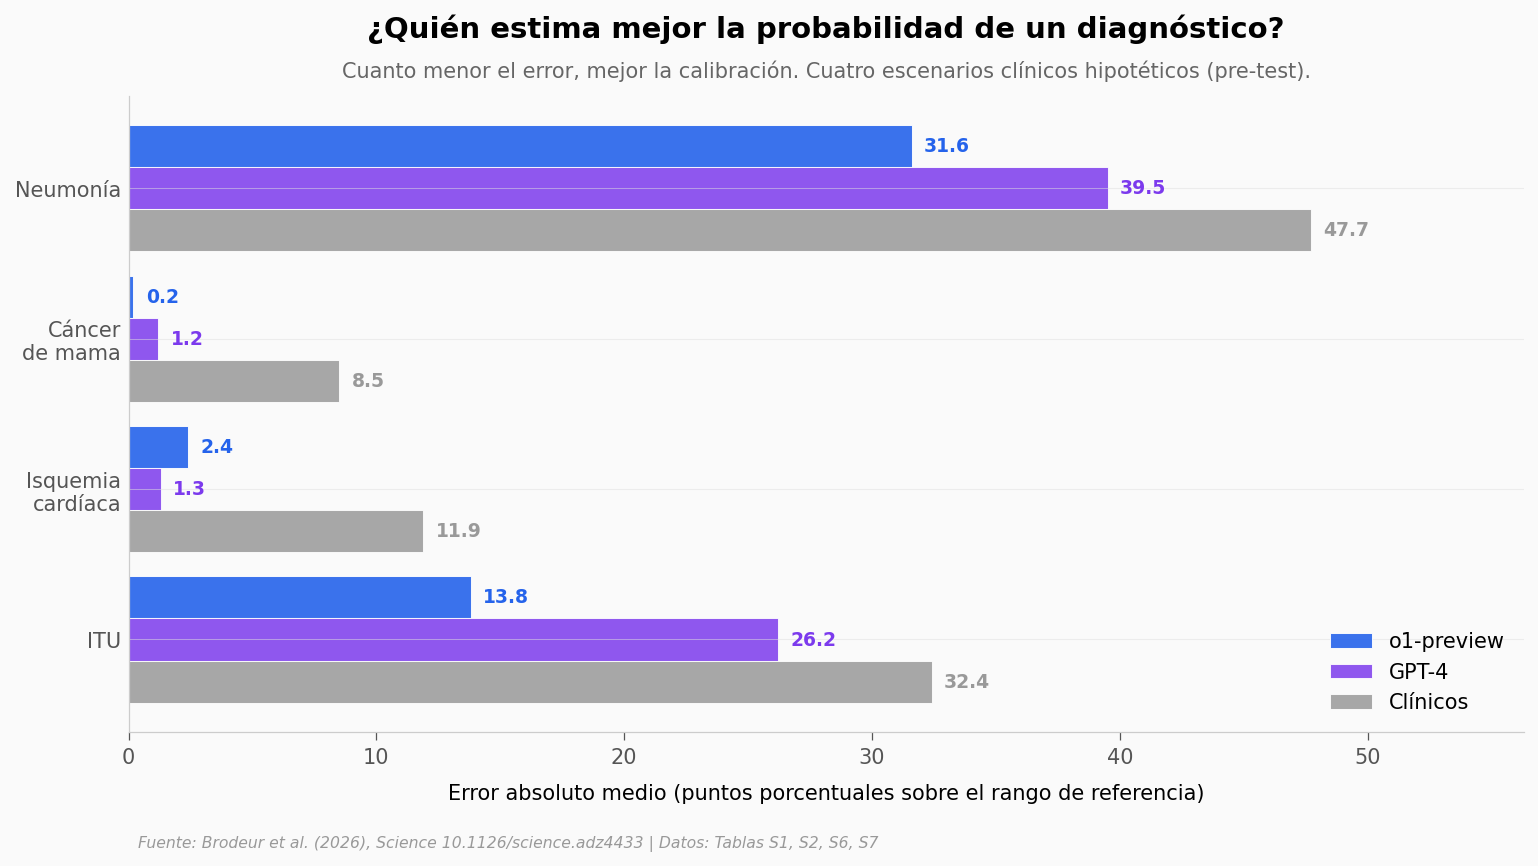

MAE medio o1: 12.00 pp
MAE medio clínicos: 25.12 pp
Ratio clínicos/o1: 2.09x


In [4]:
# Razonamiento probabilístico: error absoluto medio (MAE) vs rangos de referencia
fig, ax = plt.subplots(figsize=(12, 5.5))

np.random.seed(42)
labels_cond = ['Neumonía',
               'Cáncer' + chr(10) + 'de mama',
               'Isquemia' + chr(10) + 'cardíaca',
               'ITU']
y_pos = np.arange(len(prob))
height = 0.28

bars_o1 = ax.barh(y_pos - height, prob['o1_mae'], height, color=COLOR_LLM,
                  alpha=0.9, edgecolor='white', linewidth=0.5, label='o1-preview')
bars_gpt = ax.barh(y_pos, prob['gpt4_mae'], height, color='#7C3AED',
                   alpha=0.85, edgecolor='white', linewidth=0.5, label='GPT-4')
bars_cli = ax.barh(y_pos + height, prob['clinicos_mae'], height, color=COLOR_HUMANO,
                   alpha=0.85, edgecolor='white', linewidth=0.5, label='Clínicos')

for bars, vals, color in [(bars_o1, prob['o1_mae'], COLOR_LLM),
                          (bars_gpt, prob['gpt4_mae'], '#7C3AED'),
                          (bars_cli, prob['clinicos_mae'], COLOR_HUMANO)]:
    for bar, val in zip(bars, vals):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}',
                fontsize=9, color=color, fontweight='bold', va='center')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels_cond, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Error absoluto medio (puntos porcentuales sobre el rango de referencia)', fontsize=10)
ax.set_xlim(0, max(prob['clinicos_mae']) * 1.18)
ax.set_title('¿Quién estima mejor la probabilidad de un diagnóstico?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cuanto menor el error, mejor la calibración. Cuatro escenarios clínicos hipotéticos (pre-test).',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='lower right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/probabilistic_reasoning.png', dpi=200, bbox_inches='tight')
plt.show()

mae_medio_o1 = prob['o1_mae'].mean()
mae_medio_cli = prob['clinicos_mae'].mean()
print(f'MAE medio o1: {mae_medio_o1:.2f} pp')
print(f'MAE medio clínicos: {mae_medio_cli:.2f} pp')
print(f'Ratio clínicos/o1: {mae_medio_cli/mae_medio_o1:.2f}x')

## ¿Pero la IA no estará simplemente recordando los casos?

Es la sospecha obvia. Los CPCs del NEJM están publicados; o1-preview fue entrenado con texto de internet hasta octubre de 2023. ¿Y si memorizó las respuestas?

El equipo diseñó dos pruebas para descartarlo. La primera: comparar el rendimiento en casos **publicados antes** del cutoff de entrenamiento contra casos **publicados después**.

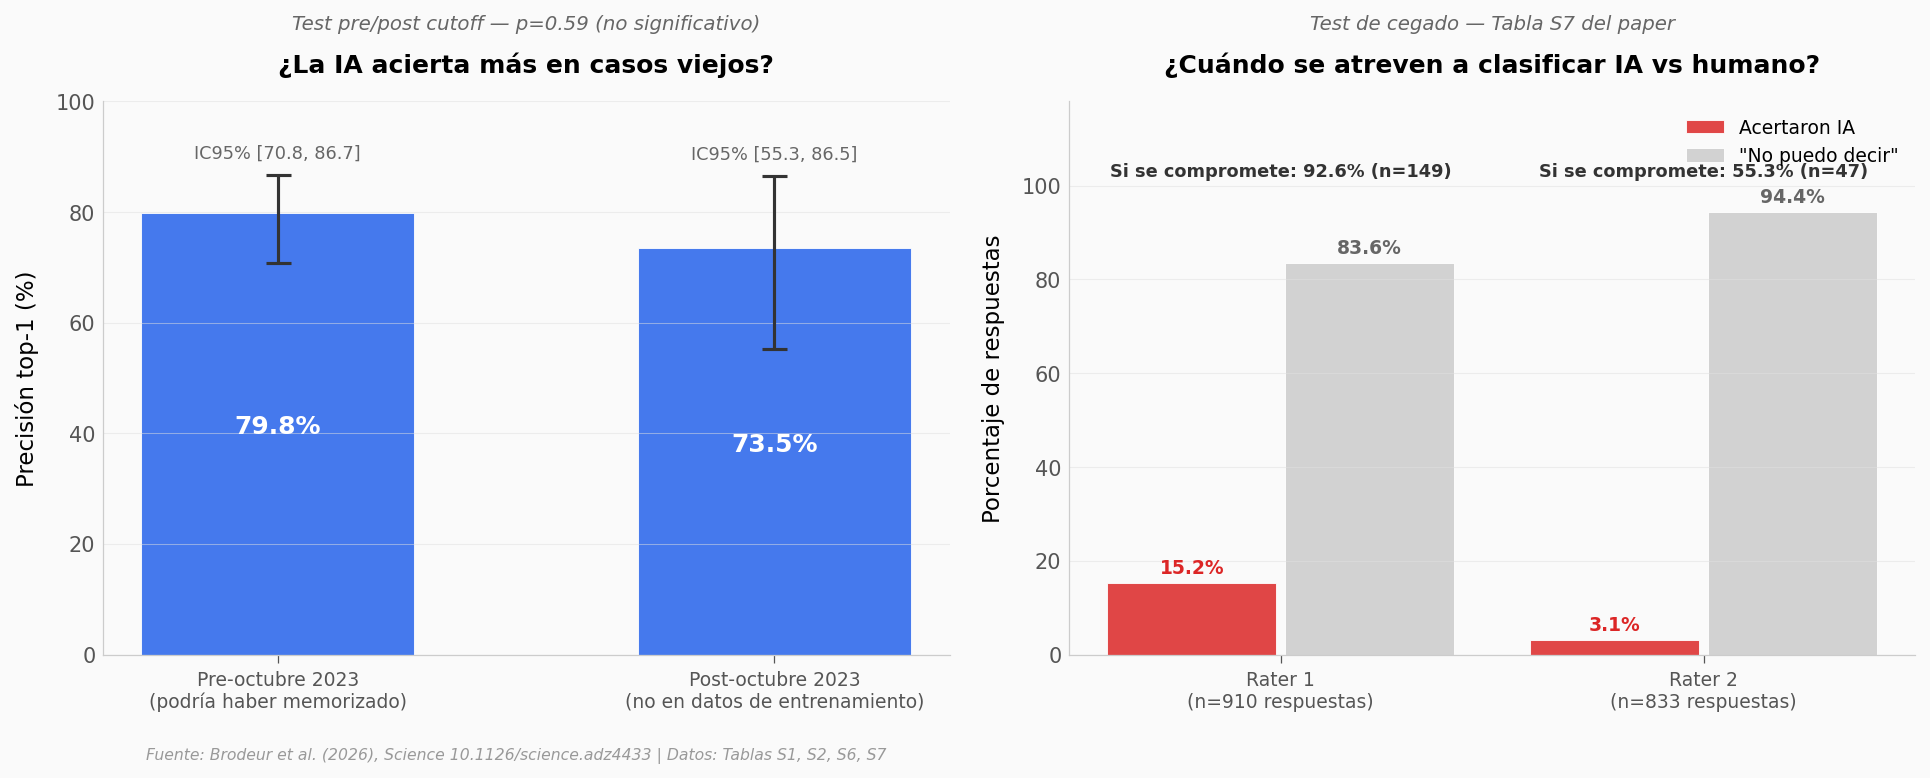

Diferencia pre/post cutoff: 6.3 pp (p=0.59)
rater_1: "no puedo decir" en 83.6% — cuando se compromete, acierta 92.6% (138/149)
rater_2: "no puedo decir" en 94.4% — cuando se compromete, acierta 55.3% (26/47)


In [5]:
# Test de memorización (pre vs post cutoff) + blinding
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: barras pre vs post con intervalos de confianza
ax = axes[0]
labels_left = ['Pre-octubre 2023' + chr(10) + '(podría haber memorizado)',
               'Post-octubre 2023' + chr(10) + '(no en datos de entrenamiento)']
pcts = cutoff['pct'].values
ci_low = cutoff['ci_low'].values
ci_high = cutoff['ci_high'].values

order = cutoff['periodo'].tolist()
idx_pre = order.index('pre_oct_2023')
idx_post = order.index('post_oct_2023')
order_idx = [idx_pre, idx_post]

x_pos = [0, 1]
for i, idx in enumerate(order_idx):
    pct = pcts[idx]
    lo = ci_low[idx]
    hi = ci_high[idx]
    err_low = pct - lo
    err_high = hi - pct
    ax.bar(i, pct, 0.55, color=COLOR_LLM, alpha=0.85,
           edgecolor='white', linewidth=0.5)
    ax.errorbar(i, pct, yerr=[[err_low], [err_high]], fmt='none',
                ecolor='#333333', capsize=6, capthick=1.5, lw=1.5)
    ax.text(i, pct/2, f'{pct:.1f}%', ha='center', fontsize=12,
            color='white', fontweight='bold')
    ax.text(i, hi + 3, f'IC95% [{lo:.1f}, {hi:.1f}]',
            ha='center', fontsize=8.5, color='#666666')

ax.set_xticks(x_pos)
ax.set_xticklabels(labels_left, fontsize=9)
ax.set_ylabel('Precisión top-1 (%)', fontsize=11)
ax.set_ylim(0, 100)
ax.set_title('¿La IA acierta más en casos viejos?', fontsize=12, fontweight='bold', pad=14)
ax.text(0.5, 1.13, 'Test pre/post cutoff — p=0.59 (no significativo)',
        transform=ax.transAxes, fontsize=9.5, color='#666666', ha='center', fontstyle='italic')

# Panel derecho: blinding test
ax = axes[1]
positions = [0, 1]
correctos = blind['pct_correctos'].values
no_distinguen = blind['pct_no_pueden_decir'].values
raters_lbl = ['Rater 1' + chr(10) + '(n=910 respuestas)',
              'Rater 2' + chr(10) + '(n=833 respuestas)']

bars_c = ax.bar([p - 0.21 for p in positions], correctos, 0.4, color=COLOR_GAP,
                alpha=0.85, edgecolor='white', linewidth=0.5, label='Acertaron IA')
bars_nd = ax.bar([p + 0.21 for p in positions], no_distinguen, 0.4, color='#CCCCCC',
                 alpha=0.85, edgecolor='white', linewidth=0.5, label='"No puedo decir"')

for bar, val in zip(bars_c, correctos):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.1f}%',
            ha='center', fontsize=9, color=COLOR_GAP, fontweight='bold')
for bar, val in zip(bars_nd, no_distinguen):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.1f}%',
            ha='center', fontsize=9, color='#666666', fontweight='bold')

# Cálculo: accuracy CONDICIONAL (cuando el rater se comprometió, ignorando 'no puedo decir')
comprometidos = blind['n_valid'].values - (blind['no_pueden_decir'].values)
acc_cond = (blind['correctos'].values / comprometidos) * 100
for i, (n_comp, acc) in enumerate(zip(comprometidos, acc_cond)):
    ax.text(i, 102, f'Si se compromete: {acc:.1f}% (n={int(n_comp)})',
            ha='center', fontsize=8.5, color='#333333', fontweight='bold')

ax.set_xticks(positions)
ax.set_xticklabels(raters_lbl, fontsize=9)
ax.set_ylabel('Porcentaje de respuestas', fontsize=11)
ax.set_ylim(0, 118)
ax.set_title('¿Cuándo se atreven a clasificar IA vs humano?',
             fontsize=12, fontweight='bold', pad=14)
ax.text(0.5, 1.13, 'Test de cegado — Tabla S7 del paper',
        transform=ax.transAxes, fontsize=9.5, color='#666666', ha='center', fontstyle='italic')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)

fig.text(0.08, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/memorization_blinding.png', dpi=200, bbox_inches='tight')
plt.show()

diff = pcts[idx_pre] - pcts[idx_post]
print(f'Diferencia pre/post cutoff: {diff:.1f} pp (p=0.59)')
# Accuracy condicional: cuando el rater se comprometió a clasificar
for i, row in blind.iterrows():
    comprometidos_n = int(row['n_valid'] - row['no_pueden_decir'])
    acc_cond_pct = row['correctos'] / comprometidos_n * 100 if comprometidos_n else 0
    print(f'{row["rater"]}: "no puedo decir" en {row["pct_no_pueden_decir"]:.1f}% — cuando se compromete, acierta {acc_cond_pct:.1f}% ({int(row["correctos"])}/{comprometidos_n})')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| o1-preview alcanzó 66.3% top-1 en CPCs (n=101) | ✅ | Tabla S2. Físicos del paper AMIE en los mismos casos: 24.3% (n=302). Gap = 42 pp, ratio 2.73× |
| El gap se cierra en urgencias reales con información completa | ✅ | Gap o1 vs Médico 1 cae de 11.8 pp (triage) a 2.7 pp (admisión); n=76 pacientes |
| La IA estima probabilidades clínicas mejor que los clínicos | ✅ | MAE medio 12.0 (o1) vs 25.12 (clínicos), 4 condiciones pre-test, Tabla S6 |
| No hay memorización de CPCs | ✅ | Pre/post cutoff: 79.8% vs 73.5%, p=0.59 (Tabla S1) |
| Médicos prefieren abstenerse de clasificar IA vs humano | ⚠️ | Rater 1: 'no puedo decir' en 83.6% (n=910); cuando se comprometió acertó 92.6% (138/149). Rater 2: 'no puedo decir' en 94.4% (n=833); acertó 55.3% (26/47) cuando se comprometió — Tabla S7 |
| El equipo humano-IA mejora al médico solo | ⚠️ | Landmark: GPT-4 solo 92% > médicos+GPT-4 76% ≈ médicos solos 74%. p=0.055 entre dyad y médicos solos — borderline, justo por encima del umbral estándar α=0.05 |
| La IA es superior en todas las tareas clínicas | ❌ | Cannot-miss diagnoses: el paper reporta la diferencia como no significativa (puntajes específicos no transcritos en las tablas Supplementary derivadas). Landmark cases: gap 18 pp, p=0.055 |

> **Limitaciones del análisis:**
> - **Rúbricas aditivas premian enumeración.** Grey Matters es un checklist sin penalización por sobre-listar. La IA enumera generosamente — parte del gap de 55 pp viene de cómo se mide, no solo de qué se mide.
> - **Controles históricos.** Brodeur compara contra benchmarks publicados entre 2021 y 2025. Los puntajes humanos vienen de cohortes y rúbricas heterogéneas. Imposible descartar *era effects* o drift de los evaluadores.
> - **Datos brutos no públicos.** Las puntuaciones por sujeto, los pacientes de urgencias y las respuestas crudas no se compartieron por confidencialidad. El repo Zenodo solo contiene código R. Reproducimos a partir de las tablas Supplementary.
> - **n=76 en el experimento más limpio.** El estudio observacional de urgencias tiene poder estadístico modesto. El propio paper pide *"urgent need for prospective trials"*.

## Ahora tú

Algunas preguntas que estos datos pueden responder con los CSVs cargados:

1. **¿Cuál es el ratio gap_triage / gap_admision para el Médico 2?** Pista: usa el DataFrame `er` y compara los pares `(triage, medico_2)` vs `(admision, medico_2)` contra o1.
2. **¿En qué condición clínica clínicos y o1 están más cerca en MAE?** Pista: calcula `prob['clinicos_mae'] / prob['o1_mae']` y busca el ratio mínimo.
3. **Si replicaras Grey Matters con una rúbrica que penalizara enumeración (resta puntos por items irrelevantes), ¿cuánto del gap de 55 pp sobreviviría?** Pista: el paper no lo midió — diseña el experimento.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ratio gap_triage / gap_admision para Médico 2

o1_triage = er[(er['touchpoint']=='triage') & (er['entidad']=='o1')]['top1_pct'].values[0]
o1_admision = er[(er['touchpoint']=='admision') & (er['entidad']=='o1')]['top1_pct'].values[0]
md2_triage = er[(er['touchpoint']=='triage') & (er['entidad']=='medico_2')]['top1_pct'].values[0]
md2_admision = er[(er['touchpoint']=='admision') & (er['entidad']=='medico_2')]['top1_pct'].values[0]

gap_triage = o1_triage - md2_triage
gap_admision = o1_admision - md2_admision

print(f'Gap o1 vs Médico 2 en triage:   +{gap_triage:.1f} pp')
print(f'Gap o1 vs Médico 2 en admisión: +{gap_admision:.1f} pp')
print(f'Ratio (admisión / triage):       {gap_admision/gap_triage:.2f}')
print()
print('A diferencia del Médico 1, donde el gap casi desaparece con info completa,')
print('para el Médico 2 el gap se mantiene mucho más ancho. ¿Qué nos dice esto')
print('sobre la variabilidad entre médicos vs la variabilidad por tarea?')

Gap o1 vs Médico 2 en triage:   +17.1 pp
Gap o1 vs Médico 2 en admisión: +11.9 pp
Ratio (admisión / triage):       0.70

A diferencia del Médico 1, donde el gap casi desaparece con info completa,
para el Médico 2 el gap se mantiene mucho más ancho. ¿Qué nos dice esto
sobre la variabilidad entre médicos vs la variabilidad por tarea?


## Fuentes

**Paper**: [Performance of a large language model on the reasoning tasks of a physician](https://doi.org/10.1126/science.adz4433)  
*Science, 2026-04-30*

**Supplementary Material**: [Tablas S1, S2, S3, S6, S7 — adz4433_sm.pdf](https://www.science.org/doi/suppl/10.1126/science.adz4433/suppl_file/science.adz4433_sm.pdf)  
*Mismo DOI que el paper; los CSVs en `datos/` se transcribieron de aquí*

**Dataset canónico**: [2v/llm-physician-tasks: v1.0.0 — código R de análisis (Brodeur et al.)](https://doi.org/10.5281/zenodo.18292046)  
*Código R original del análisis. Datos a nivel de sujeto no públicos por PHI*

*18 afirmaciones del notebook verificadas contra estas fuentes*

---

**Licencia datos derivados:** CC-BY 4.0 — los CSVs en `datos/` son transcripciones de las tablas Supplementary del paper. Atribución: Brodeur et al. (2026), Science.

**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)